# TTM Zero-Shot Baseline — 정리본

`sensor_01 / co`를 zero-shot TTM으로 검증합니다.

## 구조
1. **셋업** (0~5): 라이브러리, 하이퍼파라미터, 데이터, 전처리기, 모델
2. **헬퍼 함수** (6~8): forecast / anomaly / plot 한 번에 처리
3. **검증 시나리오** (9~10): 평탄 구간 + spike 구간

## 실행 방법
위에서 아래로 한 번씩 `Shift+Enter`. 셀 9·10은 시점만 바꿔서 반복 실행 가능.

## 0. 라이브러리

In [1]:
import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tsfm_public import (
    TinyTimeMixerForPrediction,
    TimeSeriesPreprocessor,
    TimeSeriesForecastingPipeline,
)

warnings.filterwarnings('ignore')
%matplotlib inline
print('torch:', torch.__version__, ' cuda:', torch.cuda.is_available())

torch: 2.10.0+cu128  cuda: False


## 1. 하이퍼파라미터

다른 센서/메트릭 검증 시 여기 두 줄만 바꾸면 됩니다 (`DEVICE_ID`, `METRIC`).

- **CAUTION/DANGER**: 가스 임계치 (SenSa 정책과 일치)
- **RESIDUAL_ABS_LIMIT**: TTM 잔차가 N ppm 넘으면 이상 (zero-shot over-prediction 대응)
- **FORECAST_WARN_COUNT**: forecast 96분 중 caution 초과 예측이 N개 이상이면 사전 경고

In [2]:
# 데이터 선택
DB_PATH    = '../SenSa/db.sqlite3'
DEVICE_ID  = 'sensor_01'
METRIC     = 'co'

# 시계열 구성
RESAMPLE   = '1min'
CONTEXT_LENGTH  = 512
FORECAST_LENGTH = 96

# 모델
HF_MODEL   = 'ibm-granite/granite-timeseries-ttm-r2'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# 이상 탐지 임계
CAUTION             = 25.0   # ppm — 절대 임계 (실측이 넘으면 즉시 이상)
DANGER              = 200.0
SIGMA_K             = 4      # 잔차 std × K 가 잔차 임계 (정상 노이즈 폭)
RESIDUAL_ABS_LIMIT  = 20.0   # ppm — 잔차 절대값 임계 (over-prediction 잡기)
FORECAST_WARN_COUNT = 10     # 사전 경고 트리거 (96분 중 N개 이상이 caution 넘으면)

print(f'device: {DEVICE}')
print(f'target: {DEVICE_ID}/{METRIC}')

device: cpu
target: sensor_01/co


## 2. 데이터 로드

In [3]:
con = sqlite3.connect(DB_PATH)
df  = pd.read_sql_query(f'''
    SELECT s.timestamp, s.{METRIC}
    FROM devices_sensordata s
    JOIN devices_device d ON d.id = s.device_id
    WHERE d.device_id = '{DEVICE_ID}' AND s.{METRIC} IS NOT NULL
    ORDER BY s.timestamp ASC
''', con, parse_dates=['timestamp'])
con.close()

df = (df.set_index('timestamp')
        .resample(RESAMPLE).mean()
        .interpolate('linear')
        .dropna()
        .reset_index())
df['series_id'] = DEVICE_ID

assert len(df) >= CONTEXT_LENGTH + FORECAST_LENGTH, '데이터 부족'

print(f'rows:    {len(df)}')
print(f'range:   {df["timestamp"].min()} ~ {df["timestamp"].max()}')
print(f'{METRIC} min/mean/max: {df[METRIC].min():.2f} / {df[METRIC].mean():.2f} / {df[METRIC].max():.2f}')

rows:    12939
range:   2026-04-27 06:24:00 ~ 2026-05-06 06:02:00
co min/mean/max: 7.60 / 14.38 / 136.07


## 3. 전처리기 (스케일러 fit, 모델 학습 아님)

In [4]:
tsp = TimeSeriesPreprocessor(
    timestamp_column='timestamp',
    id_columns=['series_id'],
    target_columns=[METRIC],
    context_length=CONTEXT_LENGTH,
    prediction_length=FORECAST_LENGTH,
    scaling=True,
    scaler_type='standard',
)
tsp.train(df)
print('preprocessor ready')

preprocessor ready


## 4. 모델 로드 (zero-shot)
첫 실행 시만 다운로드, 이후엔 캐시.

In [5]:
model = TinyTimeMixerForPrediction.from_pretrained(HF_MODEL).to(DEVICE).eval()

pipeline = TimeSeriesForecastingPipeline(
    model=model,
    feature_extractor=tsp,
    device=DEVICE,
    batch_size=1,
)
print('model + pipeline ready')

Device set to use cpu


model + pipeline ready


## 5. 헬퍼: run_forecast

시작 시점을 받아 그 시점부터 96분을 예측합니다.

- `start_time=None` → 데이터 끝(마지막 96분)
- `start_time=pd.Timestamp(...)` → 해당 시점부터 96분 (spike 검증용)

In [6]:
def run_forecast(start_time=None):
    """start_time 기준 96분을 예측하고 (preds, actuals, ts) 반환."""
    if start_time is None:
        # 마지막 구간
        test_input  = df.iloc[-(CONTEXT_LENGTH + FORECAST_LENGTH):-FORECAST_LENGTH].copy()
        test_target = df.iloc[-FORECAST_LENGTH:].copy()
    else:
        idx = df[df['timestamp'] >= start_time].index[0]
        start = max(0, idx - CONTEXT_LENGTH)
        end   = min(len(df), idx + FORECAST_LENGTH)
        test_input  = df.iloc[start : start + CONTEXT_LENGTH].copy()
        test_target = df.iloc[start + CONTEXT_LENGTH : end].copy()

    fc = pipeline(test_input)
    preds   = np.asarray(fc[f'{METRIC}_prediction'].iloc[0], dtype=float)
    actuals = test_target[METRIC].values
    ts      = test_target['timestamp'].values
    return preds, actuals, ts

## 6. 헬퍼: detect_anomalies

세 조건 OR로 이상 판정:
1. 잔차 std 기반 (bias 보정 후 K×σ 초과)
2. 잔차 절대값 임계 초과 (zero-shot over-prediction)
3. 실측이 caution 직접 초과

In [7]:
def detect_anomalies(preds, actuals):
    residuals = actuals - preds
    residuals_centered = residuals - residuals.mean()
    thresh = SIGMA_K * np.std(residuals_centered)

    anomaly = (
        (np.abs(residuals_centered) > thresh) |
        (np.abs(residuals) > RESIDUAL_ABS_LIMIT) |
        (actuals >= CAUTION)
    )

    forecast_exceed = int((preds >= CAUTION).sum())
    forecast_warn   = forecast_exceed >= FORECAST_WARN_COUNT

    return {
        'residuals': residuals,
        'residuals_centered': residuals_centered,
        'thresh': thresh,
        'anomaly': anomaly,
        'forecast_exceed': forecast_exceed,
        'forecast_warn': forecast_warn,
    }

## 7. 헬퍼: plot_result

In [8]:
def plot_result(ts, actuals, preds, info, title_tag=''):
    anomaly = info['anomaly']
    residuals = info['residuals']
    thresh = info['thresh']

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax = axes[0]
    ax.plot(ts, actuals, label='actual',       color='#1f77b4', alpha=0.85)
    ax.plot(ts, preds,   label='TTM forecast', color='#ff7f0e', alpha=0.85, linewidth=1.5)
    if anomaly.any():
        ax.scatter(ts[anomaly], actuals[anomaly], color='red', s=22, zorder=5, label='anomaly')
    ax.axhline(CAUTION, color='orange', ls='--', alpha=0.5, label=f'caution {CAUTION}')
    ax.axhline(DANGER,  color='red',    ls='--', alpha=0.5, label=f'danger {DANGER}')
    ax.set_ylabel(f'{METRIC.upper()} (ppm)')
    ax.set_title(f'{DEVICE_ID} {METRIC.upper()} — TTM zero-shot  [{title_tag}]')
    ax.legend(loc='upper left')

    ax = axes[1]
    ax.plot(ts, residuals, color='gray', alpha=0.75)
    ax.axhline( thresh, color='red', ls='--', alpha=0.5)
    ax.axhline(-thresh, color='red', ls='--', alpha=0.5)
    ax.set_ylabel('residual'); ax.set_xlabel('time')

    plt.tight_layout()
    plt.show()


def print_summary(info, label):
    print(f'─── {label} ───')
    print(f"  residual mean (bias): {info['residuals'].mean():+.2f}")
    print(f"  residual std:         {np.std(info['residuals_centered']):.2f}")
    print(f"  residual abs max:     {np.max(np.abs(info['residuals'])):.2f}")
    print(f"  threshold (±):        {info['thresh']:.2f}")
    print(f"  anomaly count:        {int(info['anomaly'].sum())} / {len(info['anomaly'])}")
    print(f"  forecast exceed:      {info['forecast_exceed']} / {FORECAST_LENGTH}")
    if info['forecast_warn']:
        print(f"  ⚠️  TTM 사전 경고 발동")
    else:
        print(f"  ✅ 사전 경고 없음")

## 8. 검증 A — 평탄 구간 (데이터 마지막 96분)

**기대**: 잔차 std 작음, anomaly 거의 없음, 사전 경고 없음.

INFO:p-51849:t-127950005465216:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': None, 'id_columns': ['series_id'], 'timestamp_column': 'timestamp', 'target_columns': ['co'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}


─── FLAT (last 96 min) ───
  residual mean (bias): -1.49
  residual std:         0.59
  residual abs max:     2.32
  threshold (±):        2.34
  anomaly count:        0 / 96
  forecast exceed:      0 / 96
  ✅ 사전 경고 없음


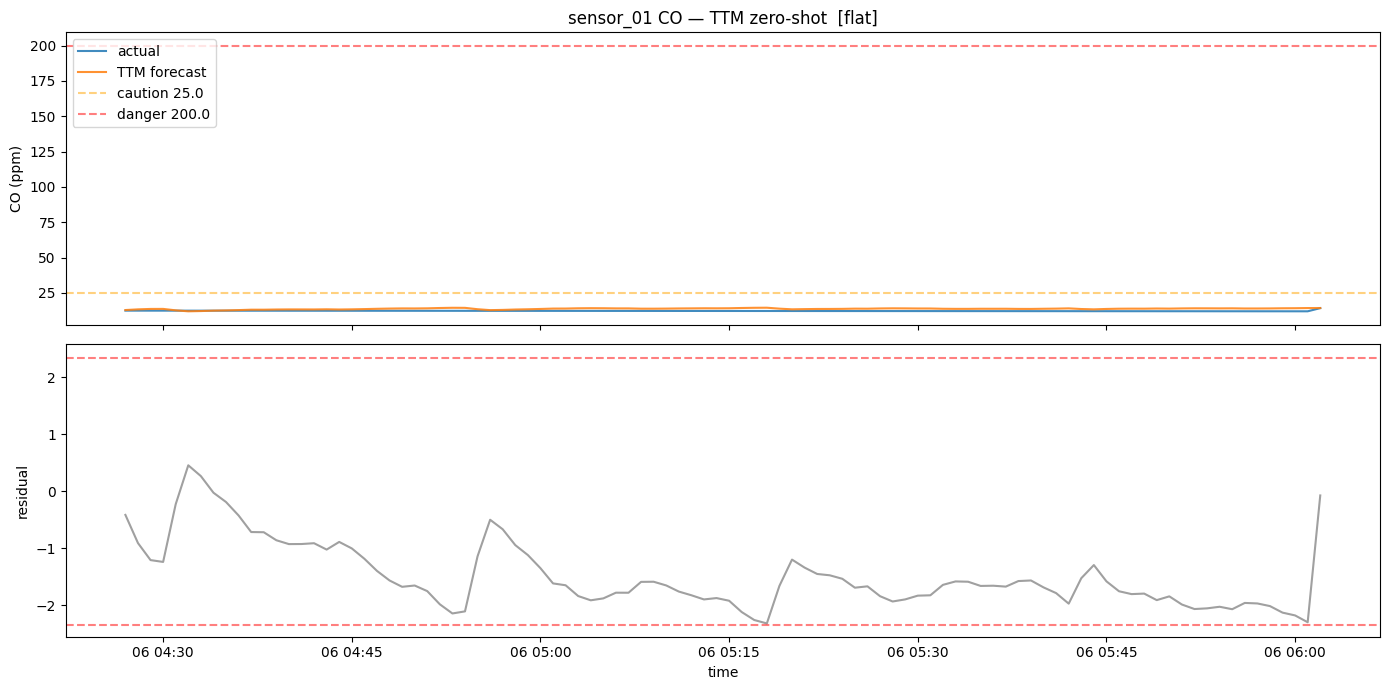

In [9]:
preds, actuals, ts = run_forecast(start_time=None)
info_flat = detect_anomalies(preds, actuals)
print_summary(info_flat, 'FLAT (last 96 min)')
plot_result(ts, actuals, preds, info_flat, title_tag='flat')

## 9. 검증 B — Spike 구간 (2026-05-06 02:00~)

**기대**: 
- spike 시작 시점(02:00~02:10): actuals가 caution 넘으며 anomaly 다수
- spike 이후(02:15~): TTM이 trend 오해로 high forecast 유지 → 잔차 큼 → anomaly 지속
- 사전 경고 발동

INFO:p-51849:t-127950005465216:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': None, 'id_columns': ['series_id'], 'timestamp_column': 'timestamp', 'target_columns': ['co'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}


─── SPIKE (2026-05-06 02:00) ───
  residual mean (bias): -108.50
  residual std:         39.43
  residual abs max:     144.83
  threshold (±):        157.73
  anomaly count:        96 / 96
  forecast exceed:      96 / 96
  ⚠️  TTM 사전 경고 발동


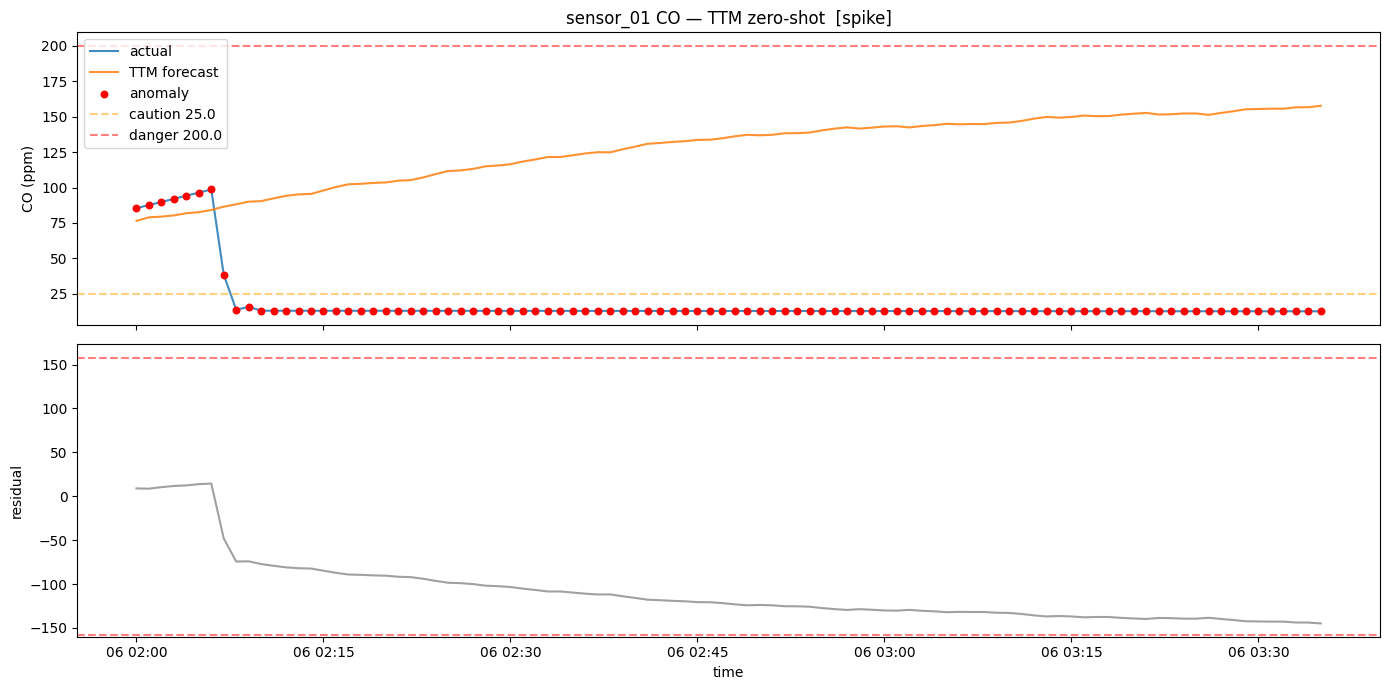

In [10]:
preds, actuals, ts = run_forecast(start_time=pd.Timestamp('2026-05-06 02:00:00'))
info_spike = detect_anomalies(preds, actuals)
print_summary(info_spike, 'SPIKE (2026-05-06 02:00)')
plot_result(ts, actuals, preds, info_spike, title_tag='spike')

## 10. 결과 비교

두 시나리오를 한 표로 정리.

In [11]:
summary = pd.DataFrame([
    {
        'scenario':      'flat',
        'residual_std':  np.std(info_flat['residuals_centered']),
        'residual_max':  np.max(np.abs(info_flat['residuals'])),
        'anomaly_n':     int(info_flat['anomaly'].sum()),
        'forecast_exceed': info_flat['forecast_exceed'],
        'forecast_warn': info_flat['forecast_warn'],
    },
    {
        'scenario':      'spike',
        'residual_std':  np.std(info_spike['residuals_centered']),
        'residual_max':  np.max(np.abs(info_spike['residuals'])),
        'anomaly_n':     int(info_spike['anomaly'].sum()),
        'forecast_exceed': info_spike['forecast_exceed'],
        'forecast_warn': info_spike['forecast_warn'],
    },
])
summary

,scenario,residual_std,residual_max,anomaly_n,forecast_exceed,forecast_warn
0,flat,0.585537,2.322624,0,0,False
1,spike,39.432000,144.829913,96,96,True


## 11. 다음 단계

이번 노트북이 잘 동작했으면 다음 검증으로 확장 가능:

```python
# 셀 1의 두 줄만 바꾸고 전체 재실행
DEVICE_ID = 'power_01'
METRIC    = 'watt'
```

가스(평균회귀)와 전력(부하변동)에서 모두 동작하면 검증 완료.  
그 다음은 FastAPI AI 서버로 모듈화.